In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import seaborn as sns

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

# set publication style for academic charts

In [4]:
data_path = '../data/processed/fred_macro_monthly.csv'

In [5]:
df = pd.read_csv(data_path, index_col = 0, parse_dates = True)

In [7]:
print('--- [Loaded Data Shape] ---')
print(df.shape)
print(df)

--- [Loaded Data Shape] ---
(306, 6)
            policy_rate      cpi  unemployment_rate  inflation_rate_yoy  \
DATE                                                                      
2001-01-01         5.98  175.600                4.2            3.721205   
2001-02-01         5.49  176.000                4.2            3.529412   
2001-03-01         5.31  176.100                4.3            2.982456   
2001-04-01         4.80  176.400                4.4            3.218256   
2001-05-01         4.21  177.300                4.3            3.563084   
...                 ...      ...                ...                 ...   
2026-03-01         3.64  330.293                4.3            3.285958   
2026-04-01         3.64  332.407                4.3            3.779246   
2026-05-01         3.63  333.979                4.3            4.166615   
2026-06-01         3.63  332.568                4.2            3.463531   
2026-07-01         3.63  332.813                4.1            

In [8]:
# compute real policy rate using the Fisher Equation 
# (real policy rate = nominal policy rate - inflation rate)

df['real_policy_rate'] = df['policy_rate'] - df['inflation_rate_yoy']

In [12]:
print('--- [Real Policy Rate] ---')
df[['policy_rate', 'inflation_rate_yoy', 'real_policy_rate']].tail()

--- [Real Policy Rate] ---


,policy_rate,inflation_rate_yoy,real_policy_rate
DATE,,,
2026-03-01,3.64,3.285958,0.354042
2026-04-01,3.64,3.779246,-0.139246
2026-05-01,3.63,4.166615,-0.536615
2026-06-01,3.63,3.463531,0.166469
2026-07-01,3.63,3.303856,0.326144


In [14]:
# monetary policy impacts the macroeconomy with long and variable transmission lags
# we construct 3-month and 6-month lagged policy rates 

df['policy_rate_lag3'] = df['policy_rate'].shift(3)
df['policy_rate_lag6'] = df['policy_rate'].shift(6)

In [15]:
print('--- [Transmission Lag Features] ---')
df[['policy_rate', 'policy_rate_lag3', 'policy_rate_lag6']].tail()

--- [Transmission Lag Features] ---


,policy_rate,policy_rate_lag3,policy_rate_lag6
DATE,,,
2026-03-01,3.64,3.72,4.33
2026-04-01,3.64,3.64,4.22
2026-05-01,3.63,3.64,3.88
2026-06-01,3.63,3.64,3.72
2026-07-01,3.63,3.64,3.64


In [16]:
# compute a 12-month rolling moving acerage for unemployment and inflation
# to isolate structural secular trend from seasonal fluctuations

df['unemployment_ma12'] = df['unemployment_rate'].rolling(window = 12).mean()
df['inflation_ma12'] = df['inflation_rate_yoy'].rolling(window = 12).mean()

In [17]:
print('--- [12-Month Moving Averages] ---')
df[['unemployment_rate', 'unemployment_ma12', 'inflation_rate_yoy', 'inflation_ma12']].tail()

--- [12-Month Moving Averages] ---


,unemployment_rate,unemployment_ma12,inflation_rate_yoy,inflation_ma12
DATE,,,,
2026-03-01,4.3,4.308333,3.285958,2.660815
2026-04-01,4.3,4.316667,3.779246,2.777254
2026-05-01,4.3,4.325000,4.166615,2.930689
2026-06-01,4.2,4.316667,3.463531,3.021211
2026-07-01,4.1,4.316667,3.303856,3.073162


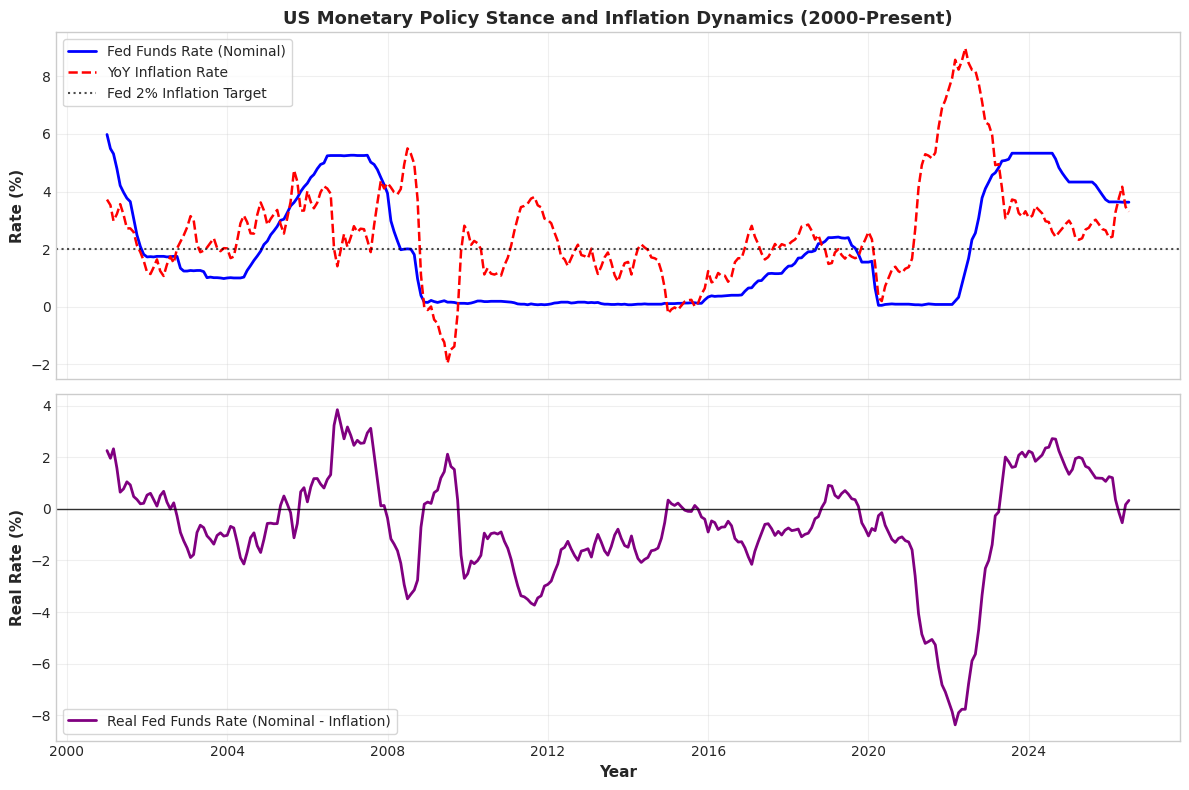

In [39]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (12, 8), sharex = True)

# Policy Rate and Inflation Rate
ax1.plot(df.index, df['policy_rate'], label = 'Fed Funds Rate (Nominal)', color = 'blue', linewidth = 2)
ax1.plot(df.index, df['inflation_rate_yoy'], label = 'YoY Inflation Rate', color = 'red', linewidth = 1.8, linestyle = '--')
ax1.axhline(2.0, color = "black", linestyle = ':', alpha = 0.7, label = 'Fed 2% Inflation Target')
ax1.set_ylabel('Rate (%)', fontsize = 11, fontweight = 'bold')
ax1.set_title ('US Monetary Policy Stance and Inflation Dynamics (2000-Present)', fontsize = 13, fontweight = 'bold')
ax1.legend (loc = 'upper left', frameon = True)
ax1.grid (True, alpha = 0.3)

# Real Interest Rate
ax2.plot(df.index, df['real_policy_rate'], label = 'Real Fed Funds Rate (Nominal - Inflation)', color = 'purple', linewidth = 2)
ax2.axhline(0, 0, color = 'black', linestyle = '-', alpha = 0.8, linewidth = 1)
ax2.set_ylabel ('Real Rate (%)', fontsize = 11, fontweight = 'bold')
ax2.set_xlabel ('Year', fontsize = 11, fontweight = 'bold')
ax2.legend (loc = 'lower left', frameon = True)
ax2.grid (True, alpha = 0.3)

plt.tight_layout()

In [40]:
fig_path = '../data/processed/us_macro_policy_dynamics.png'
plt.savefig (fig_path, dpi = 300) 
plt.show()

<Figure size 640x480 with 0 Axes>

In [41]:
print(f"Chart saved successfully to: {fig_path}")

Chart saved successfully to: ../data/processed/us_macro_policy_dynamics.png
